<a href="https://colab.research.google.com/github/tavish-1721/DSA-Bootcamp-2026/blob/main/Customer_Churn_Prediction_using_ANN_%7C_Keras_and_Tensorflow_%7C_Deep_Learning_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
import kagglehub

path = kagglehub.dataset_download("shubh0799/churn-modelling")
print("Path to dataset files:", path)

import os
print(os.listdir(path))
df = pd.read_csv(path + '/Churn_Modelling.csv')

print(df.shape)

Using Colab cache for faster access to the 'churn-modelling' dataset.
Path to dataset files: /kaggle/input/churn-modelling
['Churn_Modelling.csv', '.nfs00000000ac5286f800000058']
(10000, 14)


In [12]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [16]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [17]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [18]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [30]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [32]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [33]:
X_train.shape

(8000, 11)

In [34]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [35]:
X_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [44]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense

In [47]:
model= Sequential()
model.add(Input(shape=(11,)))
model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144 (576.00 B)

 Trainable params: 144 (576.00 B)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
history=model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2)  #if validation accuracy is not increasing, then overfitting.

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7934 - loss: 0.4917 - val_accuracy: 0.7987 - val_loss: 0.4598
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7931 - loss: 0.4590 - val_accuracy: 0.8012 - val_loss: 0.4370
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7964 - loss: 0.4441 - val_accuracy: 0.8112 - val_loss: 0.4253
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8031 - loss: 0.4365 - val_accuracy: 0.8181 - val_loss: 0.4195
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8067 - loss: 0.4326 - val_accuracy: 0.8200 - val_loss: 0.4164
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8119 - loss: 0.4301 - val_accuracy: 0.8269 - val_loss: 0.4145
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8139 - loss: 0.4282 - val_accuracy: 0.8275 - val_loss: 0.4130
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8147 - loss: 0.4266 - val_accuracy: 0.

In [49]:
model.layers[0].get_weights()

[array([[ 0.13998863,  0.1905586 , -0.4365292 ,  0.3503238 ,  0.24058616,
          0.1193307 , -0.35875222,  0.0579571 , -0.05405917,  0.21857844,
         -0.1963138 ],
        [-0.33484527, -1.0710732 , -0.01854668, -0.7601951 , -1.3587346 ,
         -0.13809676, -0.27913973, -1.4716365 ,  0.03311967,  1.3264999 ,
         -0.6348592 ],
        [ 0.14710678, -0.17075016,  0.05464476, -0.02162026,  0.21438986,
          0.04397031,  0.08692154, -0.31224203,  0.0036781 , -0.02680173,
          0.04062872],
        [-0.21030256,  0.11033617, -0.24946196,  0.22166455, -0.27914447,
         -0.14597866,  0.00712022, -0.00675128,  0.25613356,  0.09777914,
         -0.3200568 ],
        [-0.10638078,  1.0551881 ,  0.18686749, -0.24551503,  0.03833589,
         -0.089713  ,  1.0051541 , -0.01761863,  0.17419806,  0.157877  ,
          0.23879474],
        [ 0.17564636, -0.26187944,  0.5902699 , -0.00943637,  0.18603444,
         -0.01800203,  0.4151612 ,  0.1924227 ,  0.07283188,  0.0539248

In [50]:
model.layers[1].get_weights()

[array([[-0.5275381 ],
        [-0.25315705],
        [ 0.32081848],
        [-0.26636302],
        [-0.98630136],
        [-0.61837494],
        [-0.6369118 ],
        [-0.7588331 ],
        [ 0.57765234],
        [ 0.66452146],
        [-0.64290476]], dtype=float32),
 array([0.01758654], dtype=float32)]

In [51]:
model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.19139972],
       [0.07945804],
       [0.31779155],
       ...,
       [0.3908321 ],
       [0.0678255 ],
       [0.18790603]], dtype=float32)

In [52]:
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [53]:
np.where(y_log>0.5,1,0)

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [56]:
from sklearn.metrics import accuracy_score
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy_score(y_test, y_pred)
accuracy_score(y_test,y_pred)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


0.8165

In [57]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.7934374809265137,
  0.7931249737739563,
  0.7964062690734863,
  0.8031250238418579,
  0.8067187666893005,
  0.8118749856948853,
  0.8139062523841858,
  0.8146874904632568,
  0.8167187571525574,
  0.8167187571525574],
 'loss': [0.4916657507419586,
  0.45895060896873474,
  0.4441361129283905,
  0.43647709488868713,
  0.4325900971889496,
  0.4301474690437317,
  0.42815399169921875,
  0.42663609981536865,
  0.4248843789100647,
  0.42304936051368713],
 'val_accuracy': [0.7987499833106995,
  0.8012499809265137,
  0.8112499713897705,
  0.8181250095367432,
  0.8199999928474426,
  0.8268749713897705,
  0.8274999856948853,
  0.8287500143051147,
  0.828125,
  0.8299999833106995],
 'val_loss': [0.45979824662208557,
  0.4369935095310211,
  0.4253496527671814,
  0.4195493459701538,
  0.4164116382598877,
  0.414524644613266,
  0.4130285382270813,
  0.41139453649520874,
  0.40975213050842285,
  0.4080195724964142]}

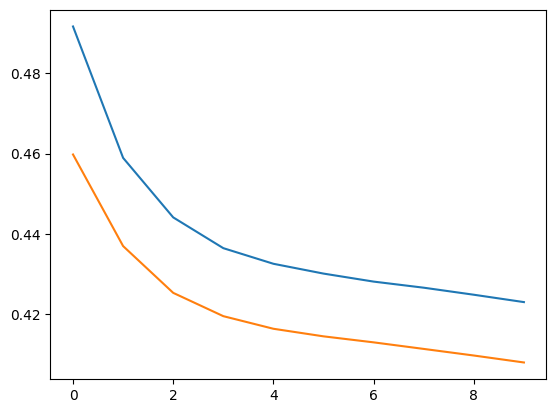

In [58]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

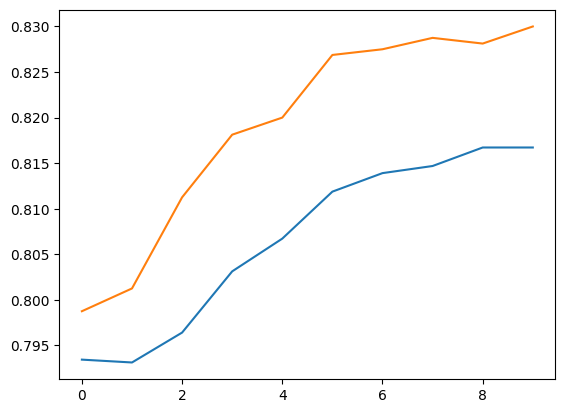

In [59]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])